<a href="https://colab.research.google.com/github/gkpkmrsubham02-png/summer-internship/blob/main/project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sns.set_theme(style="whitegrid")

In [ ]:
df = pd.read_csv('/content/amazon.csv', on_bad_lines='skip', engine='python')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 621 entries, 0 to 620
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           621 non-null    object 
 1   product_name         621 non-null    object 
 2   category             621 non-null    object 
 3   discounted_price     621 non-null    object 
 4   actual_price         621 non-null    object 
 5   discount_percentage  621 non-null    object 
 6   rating               621 non-null    float64
 7   rating_count         619 non-null    object 
 8   about_product        621 non-null    object 
 9   user_id              621 non-null    object 
 10  user_name            621 non-null    object 
 11  review_id            621 non-null    object 
 12  review_title         621 non-null    object 
 13  review_content       621 non-null    object 
 14  img_link             621 non-null    object 
 15  product_link         621 non-null    obj

In [ ]:
# A. Clean Price Columns (Remove '₹' and ',' then convert to float)
price_cols = ['discounted_price', 'actual_price']
for col in price_cols:
    df[col] = df[col].astype(str).str.replace('₹', '', regex=False)
    df[col] = df[col].astype(str).str.replace(',', '', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [ ]:
# B. Clean Discount Percentage (Remove '%' and convert to float/100)
df['discount_percentage'] = df['discount_percentage'].astype(str).str.replace('%', '', regex=False)
df['discount_percentage'] = pd.to_numeric(df['discount_percentage'], errors='coerce') / 100

In [ ]:
# C. Clean Rating Column (Handle unusual characters like '|' or text)
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

In [ ]:
# D. Clean Rating Count (Remove ',' and convert to numeric)
df['rating_count'] = df['rating_count'].astype(str).str.replace(',', '', regex=False)
df['rating_count'] = pd.to_numeric(df['rating_count'], errors='coerce')

In [ ]:
# E. Handle Missing Values (Impute or drop)
# For ratings and rating counts, we can fill missing values with the median
df['rating'] = df['rating'].fillna(df['rating'].median())
df['rating_count'] = df['rating_count'].fillna(df['rating_count'].median())

In [ ]:
print("Displaying the count of missing values per column:")
display(df.isnull().sum())

Displaying the count of missing values per column:


,0
product_id,0
product_name,0
category,0
discounted_price,0
actual_price,0
discount_percentage,0
rating,0
rating_count,0
about_product,0
user_id,0


In [ ]:
# For prices, we can drop rows if critical financial data is missing
df = df.dropna(subset=['discounted_price', 'actual_price'])

In [ ]:
print("Displaying descriptive statistics for numerical columns:")
display(df.describe())

Displaying descriptive statistics for numerical columns:


,discounted_price,actual_price,discount_percentage,rating,rating_count
count,621.000000,621.000000,621.000000,621.000000,621.000000
mean,4874.112705,8151.663961,0.529356,4.105314,25328.845411
std,9714.036105,14725.604201,0.209338,0.264735,55425.506204
min,50.000000,50.000000,0.000000,2.800000,5.000000
25%,290.000000,799.000000,0.380000,4.000000,1269.000000
50%,599.000000,1500.000000,0.570000,4.100000,7779.000000
75%,2599.000000,8499.000000,0.690000,4.300000,24269.000000
max,77990.000000,139900.000000,0.910000,5.000000,426973.000000


In [ ]:
# Categories are separated by '|', let's grab the primary top-level category
df['main_category'] = df['category'].astype(str).apply(lambda x: x.split('|')[0])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 621 entries, 0 to 620
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           621 non-null    object 
 1   product_name         621 non-null    object 
 2   category             621 non-null    object 
 3   discounted_price     621 non-null    float64
 4   actual_price         621 non-null    float64
 5   discount_percentage  621 non-null    float64
 6   rating               621 non-null    float64
 7   rating_count         621 non-null    float64
 8   about_product        621 non-null    object 
 9   user_id              621 non-null    object 
 10  user_name            621 non-null    object 
 11  review_id            621 non-null    object 
 12  review_title         621 non-null    object 
 13  review_content       621 non-null    object 
 14  img_link             621 non-null    object 
 15  product_link         621 non-null    obj

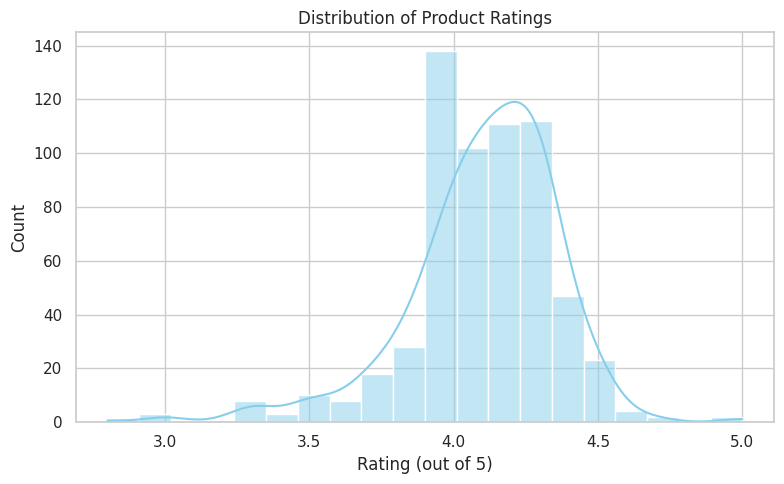

In [ ]:
# Plot 1: Distribution of Ratings
plt.figure(figsize=(8, 5))
sns.histplot(df['rating'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Product Ratings')
plt.xlabel('Rating (out of 5)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1024/292692764.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.values, y=top_categories.index, palette='viridis')


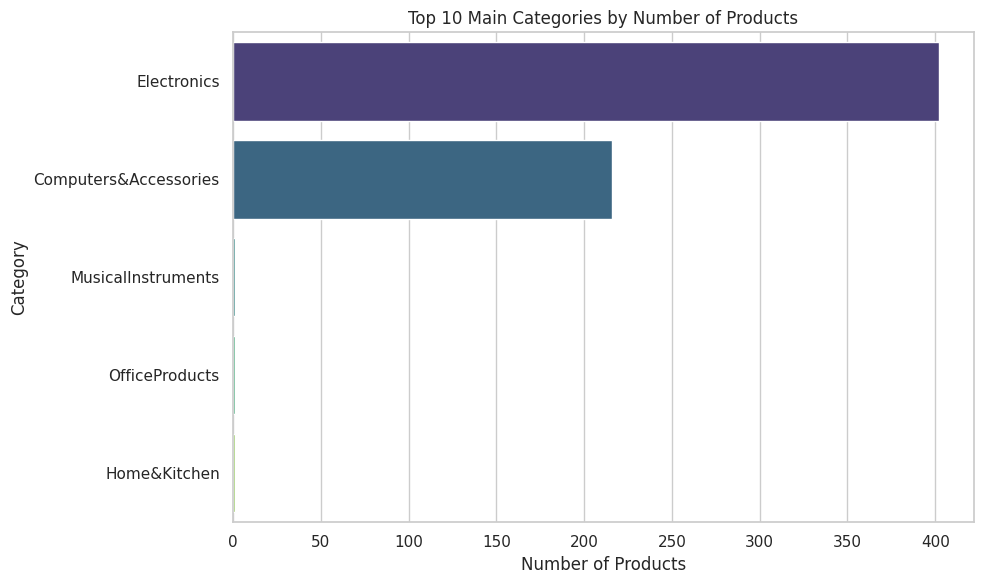

In [ ]:
# Plot 2: Top 10 Main Categories by Product Count
plt.figure(figsize=(10, 6))
top_categories = df['main_category'].value_counts().head(10)
sns.barplot(x=top_categories.values, y=top_categories.index, palette='viridis')
plt.title('Top 10 Main Categories by Number of Products')
plt.xlabel('Number of Products')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

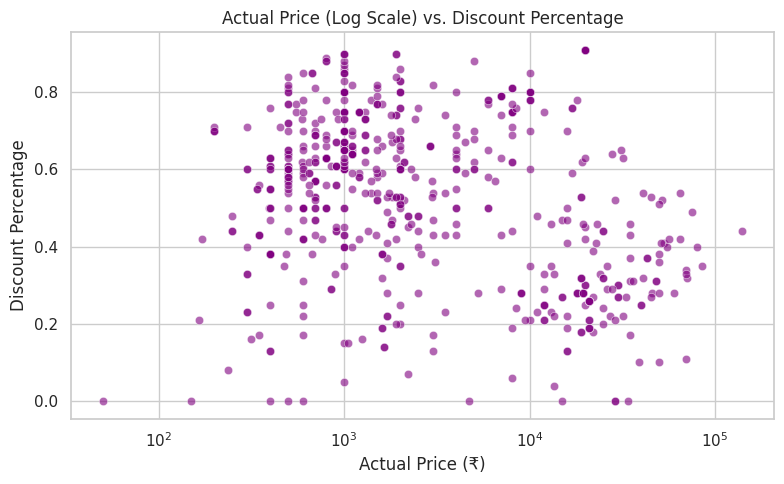

In [ ]:
# Plot 3: Relationship Between Actual Price and Discount Percentage
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='actual_price', y='discount_percentage', alpha=0.6, color='purple')
plt.xscale('log')  # Using log scale since prices can have a massive range
plt.title('Actual Price (Log Scale) vs. Discount Percentage')
plt.xlabel('Actual Price (₹)')
plt.ylabel('Discount Percentage')
plt.tight_layout()
plt.show()

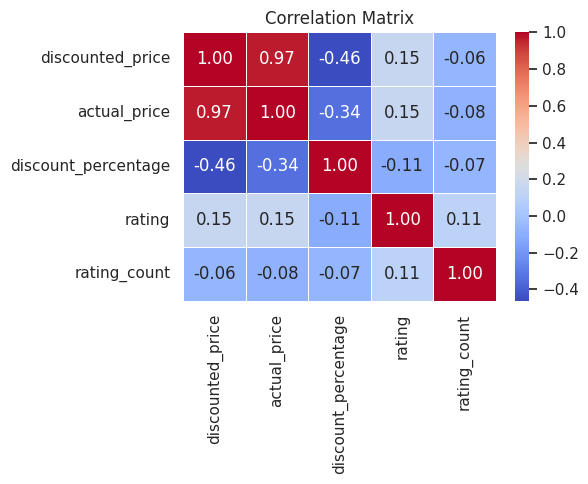

In [ ]:
# Plot 4: Correlation Heatmap between Numeric Variables
plt.figure(figsize=(6, 5))
numeric_cols = ['discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count']
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()